# Advanced Time Series Forecasting, Optimization and Explainability

**Course:** Advanced Topics in Deep Learning — 2nd Semester 2025/2026

**Dataset:** Jena Climate (Weather) — Air Temperature Forecasting

**Task:** Multivariate-input, univariate-output, multi-step forecasting

---

**Group Members:**
- David Isaac — 1200...
- David Volovei — 1200...
- Eduardo Martins — 120063

## Table of Contents

1. [Setup & Imports](#1-setup--imports)
2. [Data Loading](#2-data-loading)
3. [Exploratory Data Analysis](#3-exploratory-data-analysis)
4. [Data Preprocessing](#4-data-preprocessing)
5. [Windowing & DataLoaders](#5-windowing--dataloaders)
6. [Baseline Models](#6-baseline-models)
7. [Evolutionary Optimization](#7-evolutionary-optimization)
8. [Synthetic Data Generation (Optional/Bonus)](#8-synthetic-data-generation-optionalbonus)
9. [Explainable AI (XAI)](#9-explainable-ai-xai)
10. [Efficiency & Resource Analysis](#10-efficiency--resource-analysis)
11. [Comparative Analysis & Discussion](#11-comparative-analysis--discussion)
12. [Conclusion](#12-conclusion)

---
## 1. Setup & Imports

Install and import all required libraries. Set random seeds for reproducibility.

# Atenção, isto é o que está a acontecer neste notebook!!!

What's reused (methodology):
The strategy for handling erroneous wind speed values (-9999 → time-of-day median)
Removing duplicate timestamps
Hourly resampling with .resample('1h').mean() + linear interpolation
Cyclic sin/cos temporal encoding
70/15/15 chronological split
StandardScaler fit on training data only
What's different (code):
Aspect	Old notebook	New code
Column names	Renames columns (wv (m/s) → WindSpeed, etc.)	Keeps original names (wv (m/s), T (degC)) to match what Section 2 of 

main.ipynb
 already established
Structure	Data cleaning and sub-sampling are in separate sections with EDA interleaved	Combined into one clean cell (4.1) since 

main.ipynb
 has a single cell for this
Variable names	Uses df, df_test, df_clean, df_hourly	Uses df_clean, df_hourly, df_subsampled to chain through the pipeline consistently
Windowing + DataLoaders	Not present — old notebook only covers data prep	Fully new code — Section 5 is entirely original
Target column tracking	N/A	Adds TARGET_IDX for windowing
What you can justify:
"The data cleaning and preprocessing pipeline in 

main.ipynb
 follows the same validated methodology developed during previous coursework on this dataset (see 

data_preparation_old.ipynb
). The specific techniques — duplicate removal, erroneous wind speed correction via time-of-day medians, hourly resampling, and cyclic temporal encoding — were previously verified to produce a clean, regular time series suitable for forecasting. The code was rewritten to integrate cleanly with the current project's architecture and extended with windowing and PyTorch DataLoader functionality not present in the original implementation."

This is completely defensible — reusing a validated approach while adapting the implementation is standard practice.

In [1]:
# !pip install -r "requirements.txt"

In [2]:
# --- Core Libraries ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import time
import warnings
warnings.filterwarnings('ignore')
import random

# --- Deep Learning ---
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# --- Scikit-learn ---
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import shap
from lime import lime_tabular


from deap import base, creator, tools, algorithms  # Option A: DEAP
# import optuna  # Option B: Optuna with evolutionary sampler

# --- Reproducibility ---
SEED = 33 # Isaac's favourite number

def set_seed(seed=SEED):
    """Set random seeds for reproducibility."""
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed()

# --- Device Configuration ---
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: NVIDIA GeForce RTX 3060 Laptop GPU


---
## 2. Data Loading

Load the Jena Climate dataset. Keep only the **required variables**:
- `Date Time` — timestamp
- `T (degC)` — air temperature (**TARGET**)
- `p (mbar)` — atmospheric pressure
- `rh (%)` — relative humidity
- `wv (m/s)` — wind speed
- `max. wv (m/s)` — maximum wind speed
- `wd (deg)` — wind direction

In [3]:
import urllib.request
import zipfile

DATA_URL = "https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip"
DATA_DIR = "data/"
DATA_FILE = os.path.join(DATA_DIR, "jena_climate_2009_2016.csv")

if not os.path.exists(DATA_FILE):
    os.makedirs(DATA_DIR, exist_ok=True)
    zip_path = os.path.join(DATA_DIR, "jena_climate_2009_2016.csv.zip")
    print("Downloading Jena Climate dataset")
    urllib.request.urlretrieve(DATA_URL, zip_path)
    print("Extracting...")
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall(DATA_DIR)
    os.remove(zip_path)
    print("Done")
else:
    print("Dataset already exists, skipping download.")

df_raw = pd.read_csv(DATA_FILE)
print(f"Raw dataset shape: {df_raw.shape}")
df_raw.head()


Dataset already exists, skipping download.
Raw dataset shape: (420551, 15)


,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,01.01.2009 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,01.01.2009 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,01.01.2009 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,01.01.2009 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3


In [4]:
REQUIRED_COLS = ['Date Time', 'T (degC)', 'p (mbar)', 'rh (%)', 'wv (m/s)', 'max. wv (m/s)', 'wd (deg)']
TARGET_COL = 'T (degC)'
df = df_raw[REQUIRED_COLS].copy()

df['Date Time'] = pd.to_datetime(df['Date Time'], format='%d.%m.%Y %H:%M:%S')
df = df.set_index('Date Time')
df = df.sort_index()


print(df.isnull().sum())
print(f"Duplicate timestamps: {df.index.duplicated().sum()}")
df.describe()

T (degC)         0
p (mbar)         0
rh (%)           0
wv (m/s)         0
max. wv (m/s)    0
wd (deg)         0
dtype: int64
Duplicate timestamps: 327


,T (degC),p (mbar),rh (%),wv (m/s),max. wv (m/s),wd (deg)
count,420551.000000,420551.000000,420551.000000,420551.000000,420551.000000,420551.000000
mean,9.450147,989.212776,76.008259,1.702224,3.056555,174.743738
std,8.423365,8.358481,16.476175,65.446714,69.016932,86.681693
min,-23.010000,913.600000,12.950000,-9999.000000,-9999.000000,0.000000
25%,3.360000,984.200000,65.210000,0.990000,1.760000,124.900000
50%,9.420000,989.580000,79.300000,1.760000,2.960000,198.100000
75%,15.470000,994.720000,89.400000,2.860000,4.740000,234.100000
max,37.280000,1015.350000,100.000000,28.490000,23.500000,360.000000


---
## 3. Exploratory Data Analysis

Understand the structure and patterns in the data before modelling.

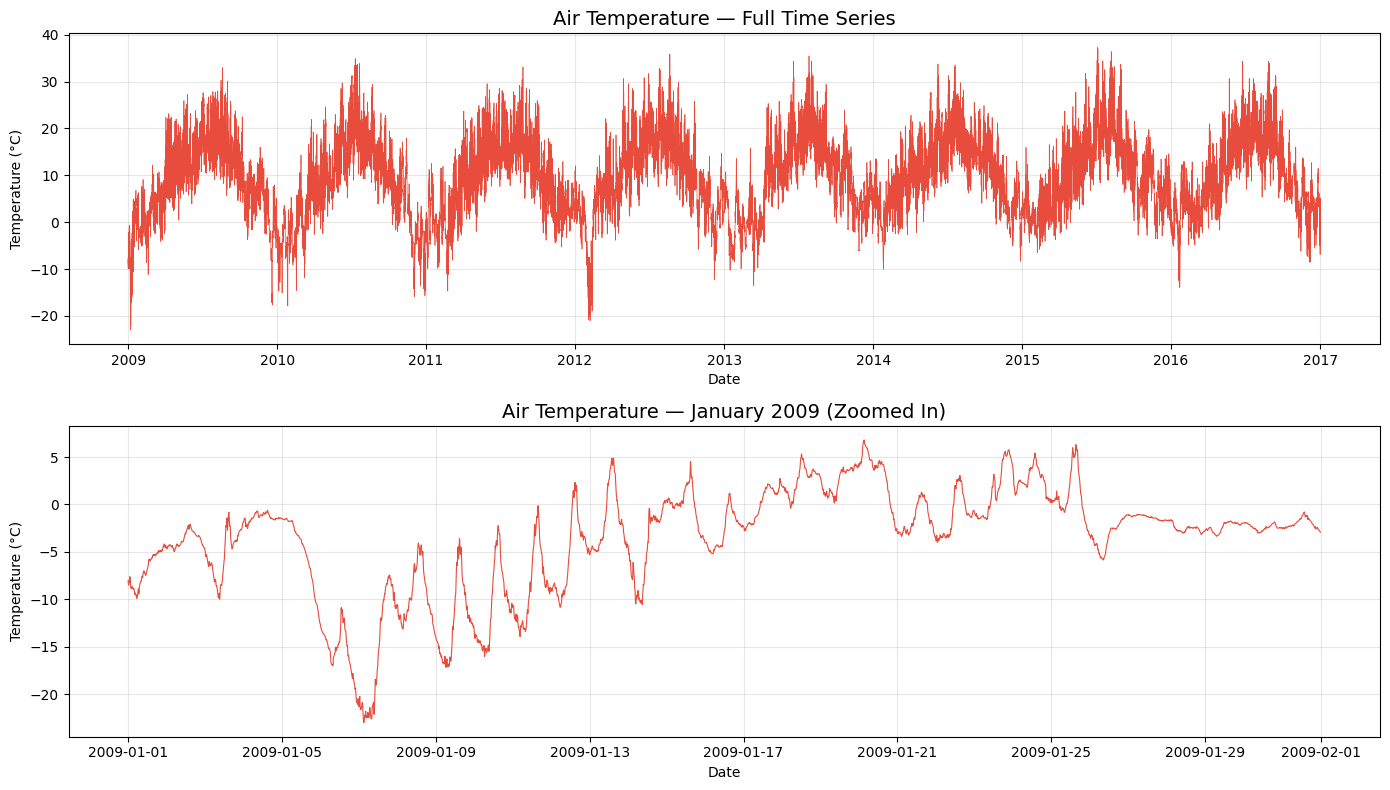

In [5]:
# --- Full time series plot ---
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(df.index, df['T (degC)'], linewidth=0.5, color='#e74c3c')
axes[0].set_title('Air Temperature — Full Time Series', fontsize=14)
axes[0].set_ylabel('Temperature (°C)')
axes[0].set_xlabel('Date')
axes[0].grid(True, alpha=0.3)

# --- Zoomed-in view: first month ---
one_month = df.loc['2009-01-01':'2009-01-31']
axes[1].plot(one_month.index, one_month['T (degC)'], linewidth=0.8, color='#e74c3c')
axes[1].set_title('Air Temperature — January 2009 (Zoomed In)', fontsize=14)
axes[1].set_ylabel('Temperature (°C)')
axes[1].set_xlabel('Date')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Comments:
# - Clear yearly seasonality (warm summers, cold winters)
# - Daily patterns visible in the zoomed view (warmer during the day, cooler at night)
# - Some noise/short-term fluctuations present, typical of weather data


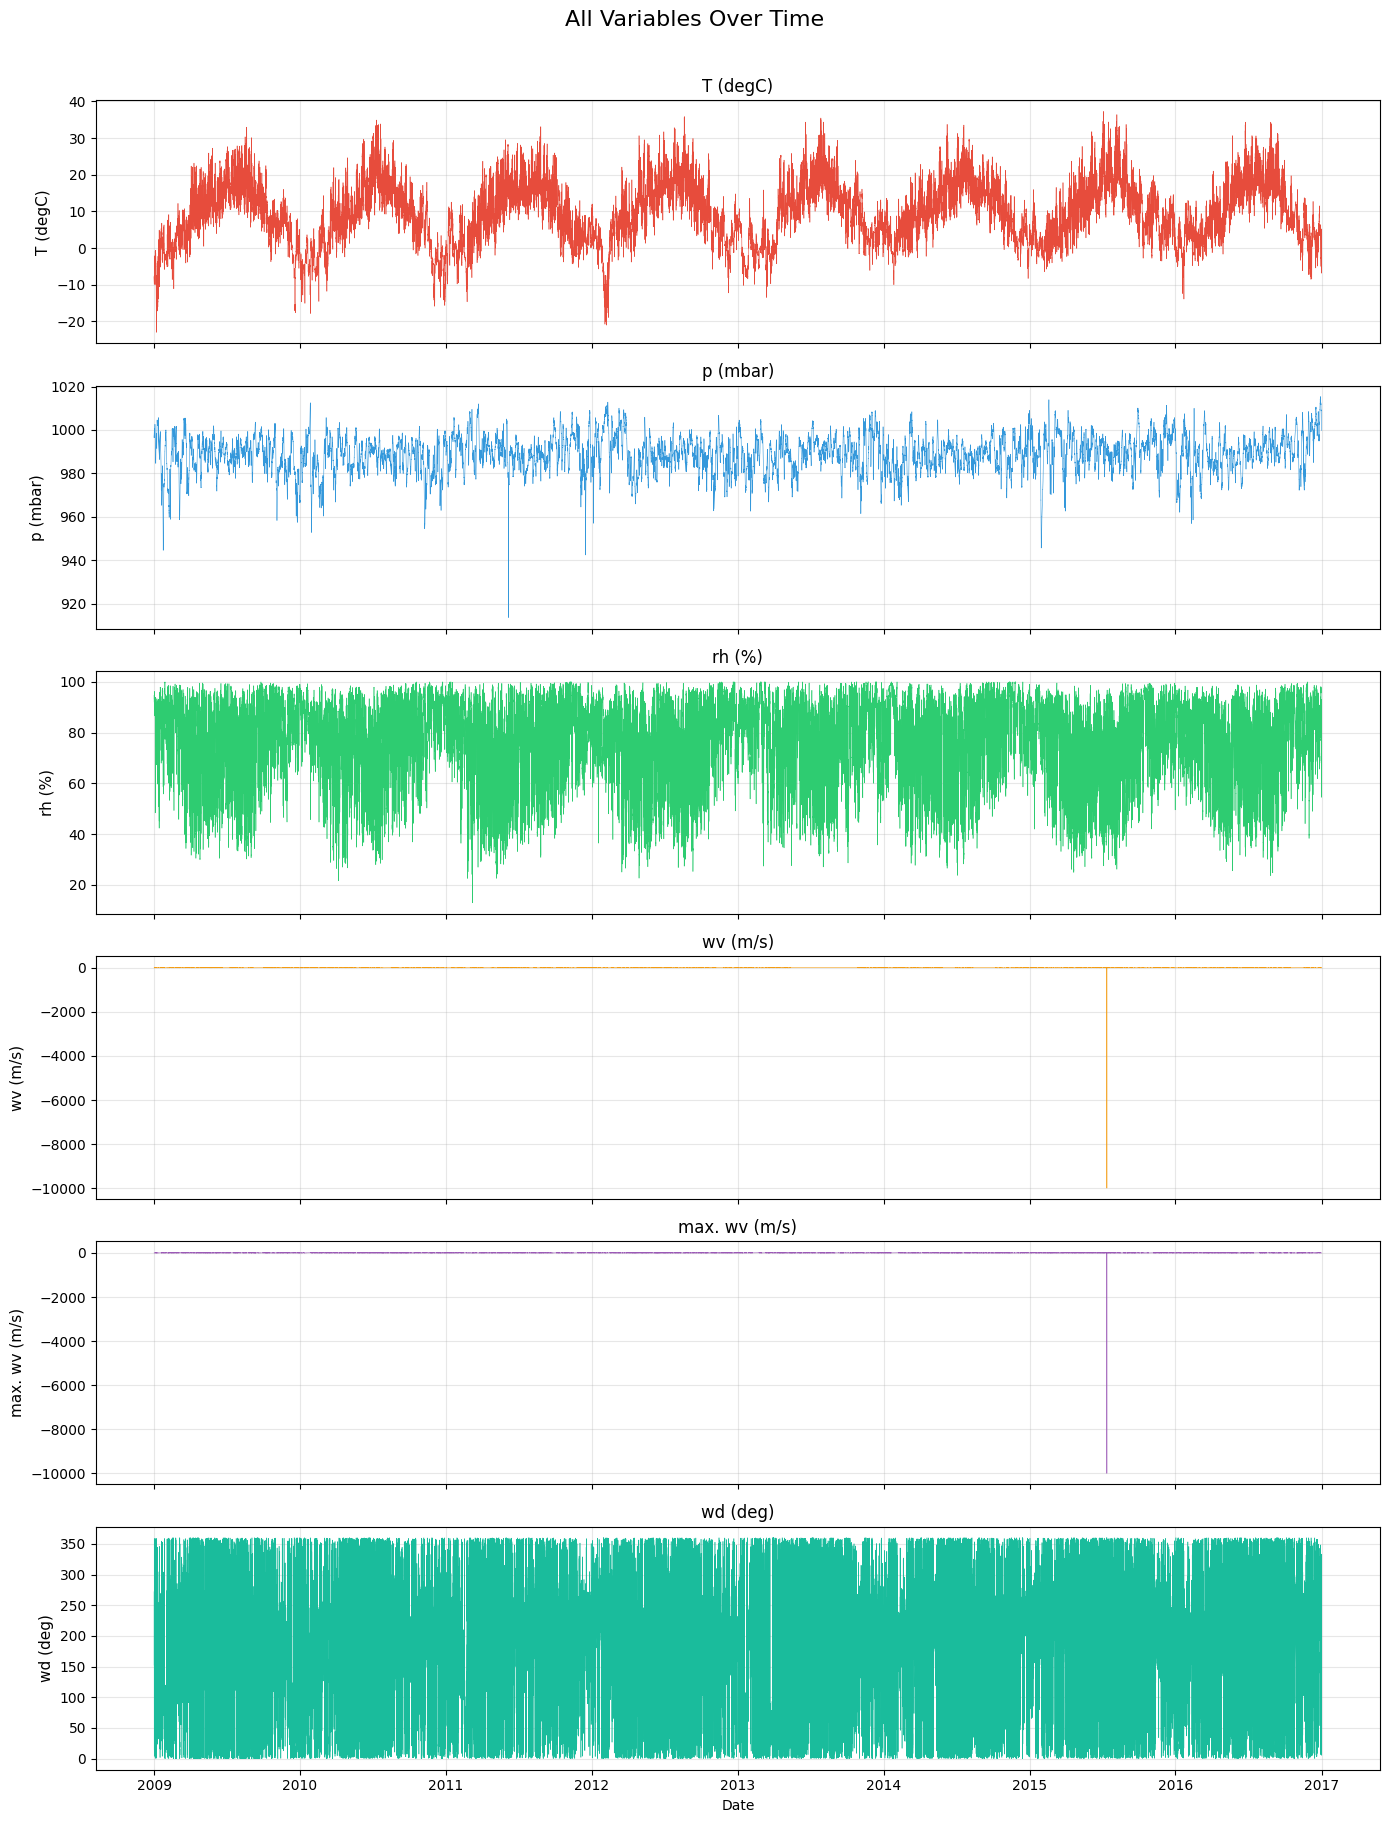

In [6]:
# Plot all input variables as subplots
feature_cols = ['T (degC)', 'p (mbar)', 'rh (%)', 'wv (m/s)', 'max. wv (m/s)', 'wd (deg)']
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c']

fig, axes = plt.subplots(len(feature_cols), 1, figsize=(14, 3 * len(feature_cols)), sharex=True)

for i, (col, color) in enumerate(zip(feature_cols, colors)):
    axes[i].plot(df.index, df[col], linewidth=0.4, color=color)
    axes[i].set_ylabel(col, fontsize=11)
    axes[i].grid(True, alpha=0.3)
    axes[i].set_title(col, fontsize=12)

axes[-1].set_xlabel('Date')
fig.suptitle('All Variables Over Time', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

# Observations:
# - Temperature and humidity show clear seasonal patterns
# - Pressure is relatively stable with some short-term weather events
# - Wind speed has sporadic spikes (potential outliers)
# - Wind direction spans 0-360° as expected


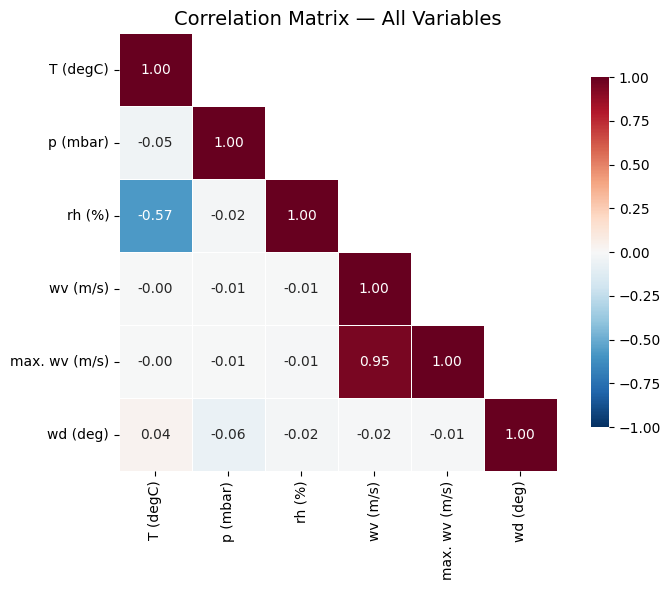

Correlations with Temperature T (degC):
wd (deg)         0.038732
max. wv (m/s)   -0.002871
wv (m/s)        -0.004689
p (mbar)        -0.045375
rh (%)          -0.572416


In [7]:
# Compute correlation matrix
corr_matrix = df.corr()

# Plot heatmap
fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            mask=mask, square=True, linewidths=0.5, ax=ax,
            vmin=-1, vmax=1, cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Matrix — All Variables', fontsize=14)
plt.tight_layout()
plt.show()

# Identify correlations with temperature
print("Correlations with Temperature T (degC):")
print(corr_matrix['T (degC)'].drop('T (degC)').sort_values(ascending=False).to_string())

# Discussion:
# - Relative humidity (rh) typically has a strong negative correlation with temperature
# - Pressure may show weak-to-moderate correlation
# - Wind variables tend to be less correlated with temperature
# - Highly correlated features may provide redundant information


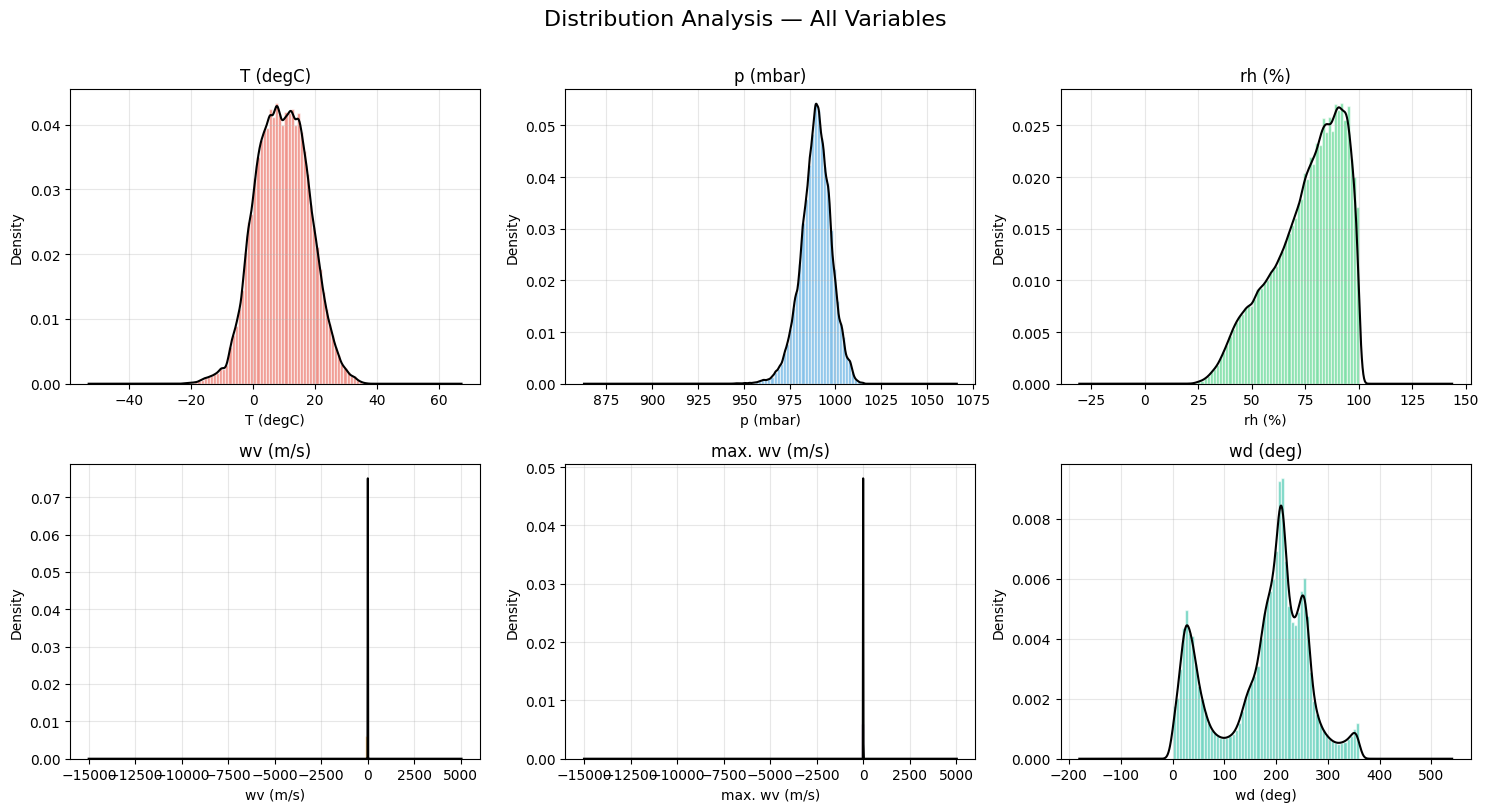

In [8]:
# Histograms + KDE for each variable
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    axes[i].hist(df[col].dropna(), bins=60, density=True, alpha=0.6, color=colors[i], edgecolor='white')
    df[col].dropna().plot.kde(ax=axes[i], color='black', linewidth=1.5)
    axes[i].set_title(col, fontsize=12)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Density')
    axes[i].grid(True, alpha=0.3)

fig.suptitle('Distribution Analysis — All Variables', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

# Observations:
# - Temperature: roughly bimodal (summer vs winter), slight negative skew
# - Pressure: approximately normal, centered around ~990 mbar
# - Humidity: left-skewed, often high values
# - Wind speed: right-skewed with some outliers at high values
# - Wind direction: multimodal (prevailing wind directions)


---
## 4. Data Preprocessing

Prepare the data for modelling: sub-sampling, temporal covariates, normalization, and splitting.

### 4.1 Sub-sampling

The original data is recorded every 10 minutes. Sub-sample to reduce computational cost.

In [9]:
# --- 4.1 Data Cleaning & Sub-sampling ---
# Step 1: Remove duplicate timestamps (keep first)
print(f"Duplicate timestamps before cleaning: {df.index.duplicated().sum()}")
df_clean = df[~df.index.duplicated(keep='first')].copy()
print(f"Records after removing duplicates: {len(df_clean)} (removed {len(df) - len(df_clean)})")

# Step 2: Fix erroneous wind speed values (-9999 sentinel values)
def fix_negative_wind_speed(df, column):
    """Replace negative wind speeds with the median of same time-of-day values."""
    negative_mask = df[column] < 0
    n_negative = negative_mask.sum()
    print(f"  Fixing {n_negative} negative values in '{column}'")
    if n_negative == 0:
        return df
    for idx in df[negative_mask].index:
        time_of_day = idx.time()
        same_time_vals = df[df.index.time == time_of_day][column]
        median_val = same_time_vals[same_time_vals >= 0].median()
        df.at[idx, column] = median_val
    return df

df_clean = fix_negative_wind_speed(df_clean, 'wv (m/s)')
df_clean = fix_negative_wind_speed(df_clean, 'max. wv (m/s)')
print(f"  Remaining negative wv: {(df_clean['wv (m/s)'] < 0).sum()}")
print(f"  Remaining negative max wv: {(df_clean['max. wv (m/s)'] < 0).sum()}")

# Step 3: Resample to hourly intervals
df_hourly = df_clean.resample('1h').mean()
print(f"\nOriginal shape (10-min):  {df_clean.shape}")
print(f"Resampled shape (hourly): {df_hourly.shape}")
print(f"Reduction factor: {len(df_clean) / len(df_hourly):.1f}x")

# Handle any NaN introduced by resampling
nan_count = df_hourly.isnull().sum().sum()
print(f"\nNaN after resampling: {nan_count}")
if nan_count > 0:
    df_hourly = df_hourly.interpolate(method='linear')
    print(f"NaN after interpolation: {df_hourly.isnull().sum().sum()}")

# Verify regular intervals
time_diffs = df_hourly.index.to_series().diff().iloc[1:]
irregular = time_diffs[time_diffs != pd.Timedelta(hours=1)]
print(f"Irregular intervals: {len(irregular)}")

df_subsampled = df_hourly.copy()
print(f"\nFinal sub-sampled shape: {df_subsampled.shape}")
df_subsampled.head(10)


Duplicate timestamps before cleaning: 327
Records after removing duplicates: 420224 (removed 327)
  Fixing 18 negative values in 'wv (m/s)'
  Fixing 20 negative values in 'max. wv (m/s)'
  Remaining negative wv: 0
  Remaining negative max wv: 0

Original shape (10-min):  (420224, 6)
Resampled shape (hourly): (70129, 6)
Reduction factor: 6.0x

NaN after resampling: 528
NaN after interpolation: 0
Irregular intervals: 0

Final sub-sampled shape: (70129, 6)


,T (degC),p (mbar),rh (%),wv (m/s),max. wv (m/s),wd (deg)
Date Time,,,,,,
2009-01-01 00:00:00,-8.304000,996.528000,93.780000,0.520000,1.002000,174.460000
2009-01-01 01:00:00,-8.065000,996.525000,93.933333,0.316667,0.711667,172.416667
2009-01-01 02:00:00,-8.763333,996.745000,93.533333,0.248333,0.606667,196.816667
2009-01-01 03:00:00,-8.896667,996.986667,93.200000,0.176667,0.606667,157.083333
2009-01-01 04:00:00,-9.348333,997.158333,92.383333,0.290000,0.670000,150.093333
2009-01-01 05:00:00,-9.716667,997.510000,92.383333,0.325000,0.813333,118.886667
2009-01-01 06:00:00,-9.298333,997.955000,92.483333,0.818333,1.501667,145.235000
2009-01-01 07:00:00,-8.543333,998.685000,93.050000,1.405000,1.941667,326.700000
2009-01-01 08:00:00,-7.926667,999.376667,92.616667,0.506667,0.876667,219.566667


### 4.2 Temporal Covariates

Engineer time-based features. Use **cyclic encoding** (sin/cos) for periodic features.

In [10]:
# --- 4.2 Temporal Covariates (Cyclic Encoding) ---
# Cyclic encoding preserves the circular nature of time:
#   - Hour 23 is close to hour 0 (not far apart like with raw integers)
#   - December is close to January

# Hour of day (period = 24)
df_subsampled['hour_sin'] = np.sin(2 * np.pi * df_subsampled.index.hour / 24)
df_subsampled['hour_cos'] = np.cos(2 * np.pi * df_subsampled.index.hour / 24)

# Day of year (period = 365.25, accounts for leap years)
df_subsampled['day_of_year_sin'] = np.sin(2 * np.pi * df_subsampled.index.dayofyear / 365.25)
df_subsampled['day_of_year_cos'] = np.cos(2 * np.pi * df_subsampled.index.dayofyear / 365.25)

# Day of week (period = 7)
df_subsampled['day_of_week_sin'] = np.sin(2 * np.pi * df_subsampled.index.dayofweek / 7)
df_subsampled['day_of_week_cos'] = np.cos(2 * np.pi * df_subsampled.index.dayofweek / 7)

print(f"Shape after adding temporal covariates: {df_subsampled.shape}")
print(f"Columns: {list(df_subsampled.columns)}")
df_subsampled.head()


Shape after adding temporal covariates: (70129, 12)
Columns: ['T (degC)', 'p (mbar)', 'rh (%)', 'wv (m/s)', 'max. wv (m/s)', 'wd (deg)', 'hour_sin', 'hour_cos', 'day_of_year_sin', 'day_of_year_cos', 'day_of_week_sin', 'day_of_week_cos']


,T (degC),p (mbar),rh (%),wv (m/s),max. wv (m/s),wd (deg),hour_sin,hour_cos,day_of_year_sin,day_of_year_cos,day_of_week_sin,day_of_week_cos
Date Time,,,,,,,,,,,,
2009-01-01 00:00:00,-8.304000,996.528000,93.780000,0.520000,1.002000,174.460000,0.000000,1.000000,0.017202,0.999852,0.433884,-0.900969
2009-01-01 01:00:00,-8.065000,996.525000,93.933333,0.316667,0.711667,172.416667,0.258819,0.965926,0.017202,0.999852,0.433884,-0.900969
2009-01-01 02:00:00,-8.763333,996.745000,93.533333,0.248333,0.606667,196.816667,0.500000,0.866025,0.017202,0.999852,0.433884,-0.900969
2009-01-01 03:00:00,-8.896667,996.986667,93.200000,0.176667,0.606667,157.083333,0.707107,0.707107,0.017202,0.999852,0.433884,-0.900969
2009-01-01 04:00:00,-9.348333,997.158333,92.383333,0.290000,0.670000,150.093333,0.866025,0.500000,0.017202,0.999852,0.433884,-0.900969


### 4.3 Train / Validation / Test Split

Use a **chronological split** (no shuffling for time series!).

- **Test set must remain UNTOUCHED** until final evaluation.
- Validation set is used for evolutionary fitness evaluation.

Train: 49,090 samples (70.0%) | 2009-01-01 00:00:00 → 2014-08-08 09:00:00
Val:   10,519 samples (15.0%) | 2014-08-08 10:00:00 → 2015-10-20 16:00:00
Test:  10,520 samples (15.0%) | 2015-10-20 17:00:00 → 2017-01-01 00:00:00


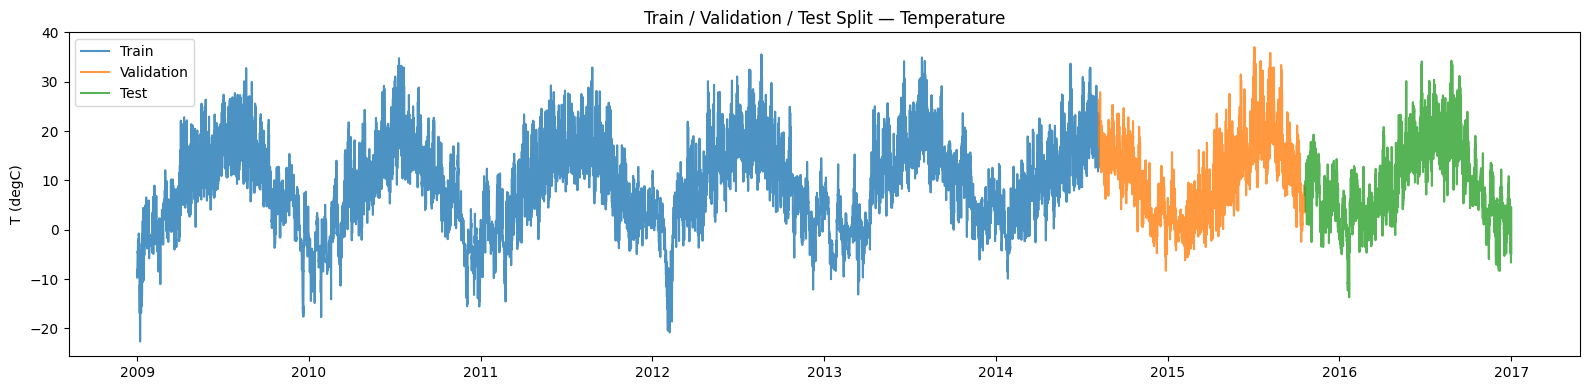

In [11]:
# --- 4.3 Chronological Train / Validation / Test Split ---
# 70% train, 15% validation, 15% test — NO SHUFFLING for time series!
n = len(df_subsampled)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

df_train = df_subsampled.iloc[:train_end].copy()
df_val   = df_subsampled.iloc[train_end:val_end].copy()
df_test  = df_subsampled.iloc[val_end:].copy()

print(f"Train: {len(df_train):,} samples ({len(df_train)/n*100:.1f}%) | "
      f"{df_train.index[0]} → {df_train.index[-1]}")
print(f"Val:   {len(df_val):,} samples ({len(df_val)/n*100:.1f}%) | "
      f"{df_val.index[0]} → {df_val.index[-1]}")
print(f"Test:  {len(df_test):,} samples ({len(df_test)/n*100:.1f}%) | "
      f"{df_test.index[0]} → {df_test.index[-1]}")

# Quick visualization of the split
fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(df_train.index, df_train[TARGET_COL], label='Train', alpha=0.8)
ax.plot(df_val.index,   df_val[TARGET_COL],   label='Validation', alpha=0.8)
ax.plot(df_test.index,  df_test[TARGET_COL],  label='Test', alpha=0.8)
ax.set_title('Train / Validation / Test Split — Temperature')
ax.set_ylabel('T (degC)')
ax.legend()
plt.tight_layout()
plt.show()


### 4.4 Normalization / Scaling

**IMPORTANT:** Fit the scaler on **training data only** to avoid data leakage.

In [12]:
# --- 4.4 Normalization ---
# StandardScaler: zero mean, unit variance
# FIT ON TRAINING DATA ONLY to prevent data leakage

scaler = StandardScaler()

train_scaled = scaler.fit_transform(df_train.values)
val_scaled   = scaler.transform(df_val.values)
test_scaled  = scaler.transform(df_test.values)

# Find target column index (for windowing later)
ALL_COLS = list(df_subsampled.columns)
TARGET_IDX = ALL_COLS.index(TARGET_COL)

print(f"Scaler fitted on training data ({len(df_train)} samples)")
print(f"Feature columns ({len(ALL_COLS)}): {ALL_COLS}")
print(f"Target column: '{TARGET_COL}' at index {TARGET_IDX}")
print(f"\nScaled shapes — Train: {train_scaled.shape}, Val: {val_scaled.shape}, Test: {test_scaled.shape}")


Scaler fitted on training data (49090 samples)
Feature columns (12): ['T (degC)', 'p (mbar)', 'rh (%)', 'wv (m/s)', 'max. wv (m/s)', 'wd (deg)', 'hour_sin', 'hour_cos', 'day_of_year_sin', 'day_of_year_cos', 'day_of_week_sin', 'day_of_week_cos']
Target column: 'T (degC)' at index 0

Scaled shapes — Train: (49090, 12), Val: (10519, 12), Test: (10520, 12)


---
## 5. Windowing & DataLoaders

Create supervised learning samples using sliding windows:

$$\mathbf{X}_{t-L+1:t} \longrightarrow \mathbf{y}_{t+1:t+H}$$

- **L** = lookback window length (number of past time steps)
- **H** = forecast horizon (number of future time steps to predict)
- **X** = multivariate input (all meteorological variables)
- **y** = univariate output (temperature only)

In [13]:
# --- 5.1 Windowing Parameters ---
# Defaults — will be optimized by evolutionary algorithm in Section 7
LOOKBACK   = 72   # 72 hours = 3 days of history
HORIZON    = 24   # 24 hours = 1 day forecast
BATCH_SIZE = 64

print(f"Lookback:   {LOOKBACK} hours ({LOOKBACK/24:.1f} days)")
print(f"Horizon:    {HORIZON} hours ({HORIZON/24:.1f} days)")
print(f"Batch size: {BATCH_SIZE}")


Lookback:   72 hours (3.0 days)
Horizon:    24 hours (1.0 days)
Batch size: 64


In [14]:
# --- 5.2 Sliding Window Function ---
def create_windows(data, target_idx, lookback, horizon):
    """
    Create sliding window samples for multi-step forecasting.

    Args:
        data: numpy array of shape (timesteps, features)
        target_idx: column index of the target variable
        lookback: L — number of past time steps as input
        horizon: H — number of future time steps to predict

    Returns:
        X: shape (num_samples, lookback, num_features)
        y: shape (num_samples, horizon)
    """
    X, y = [], []
    for i in range(lookback, len(data) - horizon + 1):
        X.append(data[i - lookback:i, :])          # all features
        y.append(data[i:i + horizon, target_idx])   # target only
    return np.array(X), np.array(y)


In [15]:
# --- 5.3 Create Windowed Datasets ---
X_train, y_train = create_windows(train_scaled, TARGET_IDX, LOOKBACK, HORIZON)
X_val,   y_val   = create_windows(val_scaled,   TARGET_IDX, LOOKBACK, HORIZON)
X_test,  y_test  = create_windows(test_scaled,  TARGET_IDX, LOOKBACK, HORIZON)

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape},   y_val:   {y_val.shape}")
print(f"X_test:  {X_test.shape},  y_test:  {y_test.shape}")

X_train: (48995, 72, 12), y_train: (48995, 24)
X_val:   (10424, 72, 12),   y_val:   (10424, 24)
X_test:  (10425, 72, 12),  y_test:  (10425, 24)


In [16]:
# --- 5.4 PyTorch Dataset & DataLoaders ---
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = TimeSeriesDataset(X_train, y_train)
val_dataset   = TimeSeriesDataset(X_val, y_val)
test_dataset  = TimeSeriesDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

# Verify a batch
X_batch, y_batch = next(iter(train_loader))
print(f"Batch X shape: {X_batch.shape}")  # (batch_size, lookback, features)
print(f"Batch y shape: {y_batch.shape}")  # (batch_size, horizon)
print(f"\nDataLoaders ready:")
print(f"  Train: {len(train_loader)} batches")
print(f"  Val:   {len(val_loader)} batches")
print(f"  Test:  {len(test_loader)} batches")


Batch X shape: torch.Size([64, 72, 12])
Batch y shape: torch.Size([64, 24])

DataLoaders ready:
  Train: 766 batches
  Val:   163 batches
  Test:  163 batches


---
## 6. Baseline Models

Train at least one baseline architecture (GRU or Transformer) from the mini-project.
This serves as the **reference** for all subsequent improvements.

### 6.1 GRU Baseline

In [17]:
class TimeSeriesGRU(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, output_dim, dropout=0.2):
        '''
        GRU-based model for multi-step time series forecasting.
        Processes the input sequence step-by-step, then uses the final hidden
        state to predict all H future values at once (Direct Multi-Step).
        '''
        super(TimeSeriesGRU, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        
        self.gru = nn.GRU(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        self.fc = nn.Linear(hidden_dim, output_dim)
        
    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(x.device)
        gru_out, _ = self.gru(x, h0)
        out = self.fc(gru_out[:, -1, :])
        return out

### 6.2 Transformer Baseline

In [18]:
# --- Positional Encoding for Transformer ---
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)

        # Create sinusoidal positional encoding matrix
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(position * div_term)  # PE(pos, 2i)
        pe[:, 1::2] = torch.cos(position * div_term)  # PE(pos, 2i+1)

        pe = pe.unsqueeze(0)  # shape: (1, max_len, d_model)
        self.register_buffer('pe', pe)  # not a learnable parameter

    def forward(self, x):
        # x shape: (batch_size, seq_len, d_model)
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)


In [19]:
class TimeSeriesTransformer(nn.Module):
    def __init__(self, input_dim, d_model, nhead, num_layers, output_dim, dropout=0.1):
        '''
        Transformer Encoder model for multi-step time series forecasting.
        Processes the entire input sequence in parallel via self-attention, then
        uses the final position's output to predict all H future values at once (Direct Multi-Step).
        '''
        super(TimeSeriesTransformer, self).__init__()
        self.d_model = d_model
        self.input_linear = nn.Linear(input_dim, d_model)
        self.pos_encoder = nn.Parameter(torch.randn(1, 200, d_model))
        encoder_layers = nn.TransformerEncoderLayer(
            d_model=d_model, 
            nhead=nhead, 
            dim_feedforward=d_model * 4,
            dropout=dropout,
            batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layers, num_layers=num_layers)
        self.decoder = nn.Linear(d_model, output_dim)
        
    def forward(self, x):
        seq_len = x.size(1)
        x = self.input_linear(x)
        x = x + self.pos_encoder[:, :seq_len, :]
        x = self.transformer_encoder(x)
        x = x[:, -1, :] 
        out = self.decoder(x)
        
        return out

### 6.3 Training Loop & Utilities

In [20]:
# --- Training function with early stopping ---
def train_model(model, train_loader, val_loader, optimizer, criterion,
                num_epochs=100, patience=10, device=DEVICE):
    """
    Train a model with early stopping and track efficiency metrics.
    Returns history dict and best model state_dict.
    """
    history = {'train_loss': [], 'val_loss': [], 'epoch_times': []}
    best_val_loss = float('inf')
    best_model_state = None
    patience_counter = 0

    total_start = time.time()

    for epoch in range(num_epochs):
        epoch_start = time.time()

        # --- Training step ---
        model.train()
        train_losses = []
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())

        # --- Validation step ---
        model.eval()
        val_losses = []
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                y_pred = model(X_batch)
                loss = criterion(y_pred, y_batch)
                val_losses.append(loss.item())

        train_loss = np.mean(train_losses)
        val_loss = np.mean(val_losses)
        epoch_time = time.time() - epoch_start

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['epoch_times'].append(epoch_time)

        # --- Early stopping ---
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = model.state_dict().copy()
            patience_counter = 0
            best_epoch = epoch + 1
        else:
            patience_counter += 1

        if (epoch + 1) % 10 == 0 or patience_counter == 0:
            print(f"Epoch {epoch+1:3d}/{num_epochs} | "
                  f"Train: {train_loss:.6f} | Val: {val_loss:.6f} | "
                  f"Time: {epoch_time:.1f}s"
                  f"{' ★' if patience_counter == 0 else ''}")

        if patience_counter >= patience:
            print(f"\nEarly stopping at epoch {epoch+1} (best: {best_epoch})")
            break

    total_time = time.time() - total_start
    history['total_time'] = total_time
    history['best_epoch'] = best_epoch
    history['best_val_loss'] = best_val_loss

    # Restore best weights
    model.load_state_dict(best_model_state)
    print(f"\nTraining complete in {total_time:.1f}s | Best epoch: {best_epoch} | Best val loss: {best_val_loss:.6f}")

    return history, best_model_state


In [21]:
# Evaluation function 
def evaluate_model(model, test_loader, criterion, scaler, target_idx, device=DEVICE):
    """
    Evaluate a trained model. Compute MSE, RMSE, MAE, R*2 in original scale.
    """
    model.eval()
    all_preds, all_targets = [], []
    inference_start = time.time() # to calculate the time that the model takes to make predictions on the test set

    with torch.no_grad(): #no gradient calculations so that we can save memory and speed up computations.
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            y_pred = model(X_batch)
            all_preds.append(y_pred.cpu().numpy())
            all_targets.append(y_batch.numpy())

    inference_time = time.time() - inference_start # After the loop, we calculate the total inference time by subtracting the start time from the current time.

    y_pred = np.concatenate(all_preds, axis=0)
    y_true = np.concatenate(all_targets, axis=0)

    # Inverse-transform to original scale (temperature only)
    target_mean = scaler.mean_[target_idx]
    target_std = scaler.scale_[target_idx]
    y_pred_orig = y_pred * target_std + target_mean
    y_true_orig = y_true * target_std + target_mean

    # Compute metrics on original scale
    mse = mean_squared_error(y_true_orig.flatten(), y_pred_orig.flatten())
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true_orig.flatten(), y_pred_orig.flatten())
    r2 = r2_score(y_true_orig.flatten(), y_pred_orig.flatten())

    # Scaled-space metrics (for comparison with old report)
    mse_scaled = mean_squared_error(y_true.flatten(), y_pred.flatten())
    mae_scaled = mean_absolute_error(y_true.flatten(), y_pred.flatten())

    results = {
        'mse': mse, 'rmse': rmse, 'mae': mae, 'r2': r2,
        'mse_scaled': mse_scaled, 'mae_scaled': mae_scaled,
        'y_true': y_true_orig, 'y_pred': y_pred_orig,
        'inference_time': inference_time,
        'num_params': sum(p.numel() for p in model.parameters()),
    }

    print(f"Test Results (original scale): MSE={mse:.4f} | RMSE={rmse:.4f} | MAE={mae:.4f} | R²={r2:.4f}")
    print(f"Test Results (scaled space):   MSE={mse_scaled:.5f} | MAE={mae_scaled:.5f}")
    print(f"Inference time: {inference_time:.2f}s | Parameters: {results['num_params']:,}")

    return results


In [22]:
# Plotting functions
def plot_training_history(history, title="Training History"):
    """Plot train and validation loss curves."""
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(history['train_loss'], label='Train Loss', alpha=0.8)
    ax.plot(history['val_loss'], label='Val Loss', alpha=0.8)
    ax.axvline(x=history['best_epoch']-1, color='r', linestyle='--', alpha=0.5, label=f"Best epoch ({history['best_epoch']})")
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss (MSE)')
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()

def plot_predictions(y_true, y_pred, title="Predictions vs Actual", n_samples=5):
    """Plot overlay of predicted and actual temperature for random samples."""
    fig, axes = plt.subplots(n_samples, 1, figsize=(14, 3 * n_samples), sharex=True)
    indices = np.random.choice(len(y_true), n_samples, replace=False)

    for ax, idx in zip(axes, sorted(indices)):
        hours = np.arange(y_true.shape[1])
        ax.plot(hours, y_true[idx], 'b-o', label='Actual', markersize=3)
        ax.plot(hours, y_pred[idx], 'r--s', label='Predicted', markersize=3)
        ax.set_ylabel('T (°C)')
        ax.legend(loc='upper right', fontsize=8)
        ax.set_title(f'Sample {idx}', fontsize=9)

    axes[-1].set_xlabel('Forecast Hour')
    fig.suptitle(title, fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()


### 6.4 Train & Evaluate Baselines

GRU Parameters: 156,696
Epoch   1/100 | Train: 0.211461 | Val: 0.102540 | Time: 2.6s ★
Epoch   2/100 | Train: 0.100929 | Val: 0.093481 | Time: 2.3s ★
Epoch   3/100 | Train: 0.093682 | Val: 0.086656 | Time: 2.5s ★
Epoch   4/100 | Train: 0.090035 | Val: 0.085540 | Time: 2.4s ★
Epoch   5/100 | Train: 0.087003 | Val: 0.084599 | Time: 2.3s ★
Epoch   6/100 | Train: 0.085035 | Val: 0.083609 | Time: 2.3s ★
Epoch   7/100 | Train: 0.083528 | Val: 0.080509 | Time: 2.3s ★
Epoch  10/100 | Train: 0.079719 | Val: 0.080099 | Time: 2.3s ★
Epoch  11/100 | Train: 0.078622 | Val: 0.078712 | Time: 2.5s ★
Epoch  12/100 | Train: 0.077755 | Val: 0.077428 | Time: 2.4s ★
Epoch  14/100 | Train: 0.075723 | Val: 0.077123 | Time: 2.4s ★
Epoch  15/100 | Train: 0.074749 | Val: 0.075682 | Time: 2.4s ★
Epoch  17/100 | Train: 0.072823 | Val: 0.075077 | Time: 2.3s ★
Epoch  20/100 | Train: 0.070422 | Val: 0.073436 | Time: 2.4s ★
Epoch  27/100 | Train: 0.066040 | Val: 0.071393 | Time: 2.2s ★
Epoch  30/100 | Train: 0.064543

TypeError: tuple indices must be integers or slices, not str

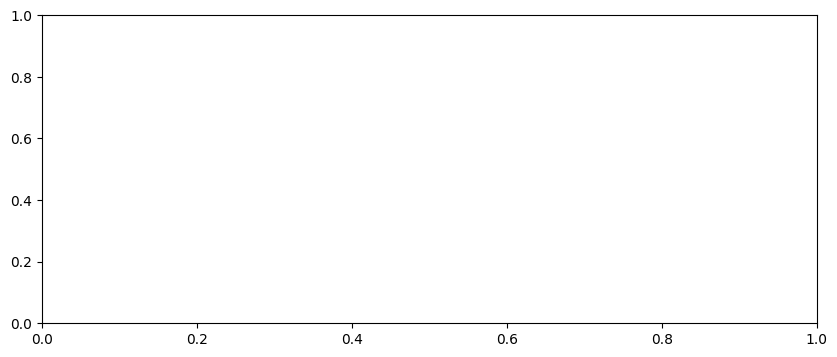

In [23]:
# Train the GRU baseline model
NUM_FEATURES = X_train.shape[2]
MODELS_DIR = "models/"
os.makedirs(MODELS_DIR, exist_ok=True)

gru_model = TimeSeriesGRU(
    input_dim=NUM_FEATURES,
    hidden_dim=128,
    num_layers=2,
    output_dim=HORIZON,
    dropout=0.5
).to(DEVICE)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(gru_model.parameters(), lr=1e-4, weight_decay=1e-4)

print(f"GRU Parameters: {sum(p.numel() for p in gru_model.parameters()):,}")
gru_history = train_model(gru_model, train_loader, val_loader, optimizer, criterion,
                          num_epochs=100, patience=10)

torch.save(gru_model.state_dict(), os.path.join(MODELS_DIR, "gru_baseline.pt"))
print(f"Model saved to {MODELS_DIR}gru_baseline.pt")
plot_training_history(gru_history, "GRU Baseline Training")


In [ ]:
# --- Evaluate GRU Baseline ---
# To load without retraining, uncomment:
# gru_model = TimeSeriesGRU(input_size=NUM_FEATURES, hidden_size=128, num_layers=2,
#                           dropout=0.5, horizon=HORIZON).to(DEVICE)
# gru_model.load_state_dict(torch.load(os.path.join(MODELS_DIR, "gru_baseline.pt"), map_location=DEVICE))

gru_results = evaluate_model(gru_model, test_loader, criterion, scaler, TARGET_IDX)
plot_predictions(gru_results['y_true'], gru_results['y_pred'], "GRU Baseline — Predictions vs Actual")


In [ ]:
# Train the Transformer baseline model
transformer_model = TimeSeriesTransformer(
    input_dim=NUM_FEATURES,
    d_model=64,
    nhead=4,
    num_layers=2,
    output_dim=HORIZON,
    dropout=0.5
).to(DEVICE)

optimizer = torch.optim.Adam(transformer_model.parameters(), lr=1e-4, weight_decay=1e-4)

print(f"Transformer Parameters: {sum(p.numel() for p in transformer_model.parameters()):,}")
transformer_history = train_model(transformer_model, train_loader, val_loader, optimizer, criterion,
                                  num_epochs=100, patience=10)

torch.save(transformer_model.state_dict(), os.path.join(MODELS_DIR, "transformer_baseline.pt"))
print(f"Model saved to {MODELS_DIR}transformer_baseline.pt")
plot_training_history(transformer_history, "Transformer Baseline Training")


In [ ]:
# --- Evaluate Transformer Baseline ---
# To load without retraining, uncomment:
# transformer_model = TimeSeriesTransformer(input_size=NUM_FEATURES, d_model=64, nhead=4,
#                                          num_layers=2, dim_feedforward=128, dropout=0.5,
#                                          horizon=HORIZON).to(DEVICE)
# transformer_model.load_state_dict(torch.load(os.path.join(MODELS_DIR, "transformer_baseline.pt"), map_location=DEVICE))

transformer_results = evaluate_model(transformer_model, test_loader, criterion, scaler, TARGET_IDX)
plot_predictions(transformer_results['y_true'], transformer_results['y_pred'], "Transformer Baseline — Predictions vs Actual")

# --- Baseline Comparison Summary ---
print("\n" + "="*60)
print("BASELINE COMPARISON")
print("="*60)
print(f"{'Metric':<20} {'GRU':>12} {'Transformer':>12}")
print("-"*44)
for m in ['mse', 'rmse', 'mae', 'r2']:
    print(f"{m.upper():<20} {gru_results[m]:>12.4f} {transformer_results[m]:>12.4f}")
print(f"{'MSE (scaled)':<20} {gru_results['mse_scaled']:>12.5f} {transformer_results['mse_scaled']:>12.5f}")
print(f"{'MAE (scaled)':<20} {gru_results['mae_scaled']:>12.5f} {transformer_results['mae_scaled']:>12.5f}")
print(f"{'Parameters':<20} {gru_results['num_params']:>12,} {transformer_results['num_params']:>12,}")
print(f"{'Inference (s)':<20} {gru_results['inference_time']:>12.2f} {transformer_results['inference_time']:>12.2f}")


---
## 7. Evolutionary Optimization

Apply **Evolutionary Algorithms** to automatically optimize the end-to-end forecasting pipeline.

This is NOT just hyperparameter tuning — it should optimize the full pipeline including:
- Model hyperparameters (hidden_size, num_layers, dropout, lr, etc.)
- Architectural choices (GRU vs Transformer, bidirectional, attention, etc.)
- Windowing strategies (lookback length, forecast horizon)
- Data preprocessing choices

**Multi-objective optimization** (e.g. error vs. complexity/efficiency) is encouraged.

### 7.1 Genotype Representation

Define what is being optimized and how it is encoded.

In [24]:
SEARCH_SPACE = {
    # Windowing parameters:
    'lookback':        [24, 48, 72, 96, 120, 168],  # hours
    'horizon':         [6, 12, 24, 48],              # hours

    # Type of model and architecture:
    'model_type':      ['gru', 'transformer'],
    'hidden_size':     [32, 64, 128, 256],
    'num_layers':      [1, 2, 3, 4],
    'dropout':         [0.0, 0.1, 0.2, 0.3, 0.5],

    # For GRU:
    'bidirectional':   [True, False],

    # For transformer:
    'nhead':           [2, 4, 8],
    'dim_feedforward': [64, 128, 256],

    # Lr and Batch size:
    'learning_rate':   [1e-4, 5e-4, 1e-3, 5e-3], 
    'batch_size':      [32, 64, 128],
}



### Search Space Justification

This table defines the "limits of evolution." Each range is chosen to balance the chance of finding a high-performing model with the available computational budget.

**Evolutionary Search Space Configuration**

| Component | Gene (Key) | Range / Options | Technical Justification |
| :--- | :--- | :--- | :--- |
| **Temporal Structure** | `lookback` | $[24, 168]$ hours | Captures short-term (1 day) up to long-term (1 week) dependencies. |
| | `horizon` | $[6, 48]$ hours | Tests model robustness across different prediction lengths (6h to 2 days). |
| **Architecture** | `model_type` | `['GRU', 'Transformer']` | Evaluates sequential processing vs. parallel self-attention mechanisms. |
| | `hidden_size` | $[32, 256]$ | Controls representational capacity; balances underfitting vs. overfitting. |
| | `num_layers` | $[1, 4]$ | Determines depth to shape gradient flow and feature abstraction. |
| **Regularization** | `dropout` | $[0.0, 0.5]$ | Essential for generalization; prevents co-adaptation of neurons. |
| **GRU Specifics** | `bidirectional` | `[True, False]` | Allows capturing patterns in both forward and backward temporal directions. |
| **Transf. Specifics**| `nhead` | $\{2, 4, 8\}$ | Defines the granularity of the multi-head attention mechanism. |
| | `dim_feedforward`| $[64, 256]$ | Adjusts the internal complexity of the Transformer's pointwise MLP. |
| **Training Dynamics**| `learning_rate` | $[10^{-4}, 5 \times 10^{-3}]$ | Critical for convergence stability and optimization speed. |
| | `batch_size` | $\{32, 64, 128\}$ | Affects gradient noise and training throughput on GPU hardware. |

### Genotype Representation

Each individual in the population is represented as a **dictionary**, acting as a **Hybrid Genotype**. This representation serves several strategic purposes in the Deep Learning pipeline:

* **Hybrid Encoding:** By using a dictionary, we can co-optimize continuous (learning rate, dropout), discrete (layers, hidden units), and categorical (model type) genes within a single individual.
* **Genotype-to-Phenotype Mapping:** The dictionary acts as a structural "blueprint" (Genotype). It is easily mapped to the actual trained Neural Network (Phenotype) by passing the dictionary keys as arguments to the model builder.
* **Interpretability:** Unlike flat lists or bitstrings, dictionaries provide clear semantic meaning for each gene, making the evolutionary process easier to debug and analyze.
* **Search Space Scalability:** This format allows us to define clear constraints (min/max values) for each key, ensuring that mutation and crossover operators always produce valid, trainable models.


### 7.1.1 Create Population

In [34]:
def create_individual():
    """Randomly sample a configuration from the search space to create an individual."""
    individual = { #random choices for each hyperparameter from the defined search space
        'lookback': np.random.choice(SEARCH_SPACE['lookback']),
        'horizon': np.random.choice(SEARCH_SPACE['horizon']),
        'model_type': np.random.choice(SEARCH_SPACE['model_type']),
        'hidden_size': np.random.choice(SEARCH_SPACE['hidden_size']),
        'num_layers': np.random.choice(SEARCH_SPACE['num_layers']),
        'dropout': np.random.choice(SEARCH_SPACE['dropout']),
        'bidirectional': np.random.choice(SEARCH_SPACE['bidirectional']),
        'nhead': np.random.choice(SEARCH_SPACE['nhead']),
        'dim_feedforward': np.random.choice(SEARCH_SPACE['dim_feedforward']),
        'learning_rate': np.random.choice(SEARCH_SPACE['learning_rate']),
        'batch_size': np.random.choice(SEARCH_SPACE['batch_size']),
    }
    return individual

def create_population(pop_size):
    """Create an initial population of individuals."""
    return [create_individual() for _ in range(pop_size)]


Population = []
Individual = None
pop_size = 10
Population = create_population(pop_size)
print(f"Created initial population of {len(Population)} individuals.")
print("Sample individual configuration:")
print("=" * 30)


print(f"{'GENE':<20} | {'VALUE':<15}")
print("-" * 38)
for key, value in Population[0].items():
    print(f"{key:<20} | {str(value):<15}")


Created initial population of 10 individuals.
Sample individual configuration:
GENE                 | VALUE          
--------------------------------------
lookback             | 72             
horizon              | 12             
model_type           | gru            
hidden_size          | 32             
num_layers           | 2              
dropout              | 0.0            
bidirectional        | True           
nhead                | 2              
dim_feedforward      | 128            
learning_rate        | 0.005          
batch_size           | 128            


### 7.1.2 Mutation and Crossover

In [35]:
def mutate(individual, mutation_rate=0.1):
    """Randomly mutate an individual's genes with a given mutation rate."""
    for gene in individual.keys():
        if np.random.rand() < mutation_rate:
            if gene in ['lookback', 'horizon', 'hidden_size', 'num_layers', 'nhead', 'dim_feedforward', 'batch_size']:
                individual[gene] = np.random.choice(SEARCH_SPACE[gene])
            elif gene in ['model_type']:
                individual[gene] = np.random.choice(SEARCH_SPACE[gene])
            elif gene in ['dropout']:
                individual[gene] = np.random.choice(SEARCH_SPACE[gene])
            elif gene in ['bidirectional']:
                individual[gene] = np.random.choice(SEARCH_SPACE[gene])
            elif gene in ['learning_rate']:
                individual[gene] = np.random.choice(SEARCH_SPACE[gene])
    return individual
    


In [36]:
def uniform_crossover(parent1, parent2):
    """uniform crossover: For each gene, randomly select from one of the two parents with equal probability."""
    child = {}
    for key in parent1.keys():
        if random.random() < 0.5:
            child[key] = parent1[key]
        else:
            child[key] = parent2[key]
    return child

def single_point_crossover(parent1, parent2):
    """ Single-point crossover: Choose a random crossover point and take genes from one parent up to that point, then from the other parent after that point."""
    child = {}
    keys = list(parent1.keys())
    
    # random crossover point between 1 and len(keys)-1 to ensure we get at least one gene from each parent
    crossover_point = random.randint(1, len(keys) - 1)
    
    for i, key in enumerate(keys):
        if i < crossover_point:
            child[key] = parent1[key]
        else:
            child[key] = parent2[key]
    return child

def create_next_population(parents, pop_size, crossover_rate=0.5, mutation_rate=0.1, crossover_choice='uniform'):
    """Create the next generation population through crossover and mutation."""
    next_population = []
    
    while len(next_population) < pop_size:
        parent1, parent2 = random.sample(parents, 2)
        
        if np.random.rand() < crossover_rate:
            if crossover_choice == 'uniform':
                child = uniform_crossover(parent1, parent2)
            elif crossover_choice == 'single_point':
                child = single_point_crossover(parent1, parent2)
            else:
                raise ValueError(f"Método de crossover desconhecido: {crossover_choice}")
        else:
            child = parent1.copy()  
        
        # The mutation is applied to the child after crossover, regardless of whether crossover occurred or not. 
        child = mutate(child, mutation_rate)
        next_population.append(child)
    
    return next_population

In [37]:
def select_parents(population, fitnesses, num_parents=10):
    """
    Selects parents using Tournament Selection, based ONLY on MSE.
    The goal is to minimize the error. Inference time is ignored in selection.
    """
    selected = []
    for _ in range(num_parents):
        # Choose 5 random individuals for the tournament
        tournament = np.random.choice(len(population), size=5, replace=False)
        tournament_fitnesses = [fitnesses[i] for i in tournament]

        # The winner is strictly the one with the LOWEST MSE (argmin)
        winner_idx = tournament[np.argmin(tournament_fitnesses)]
        selected.append(population[winner_idx])
    return selected

### 7.2 Fitness Function

**IMPORTANT:** Fitness must be computed on the **validation set only** (not test set).

In [38]:
def import_parameters(individual):
    """Extract and cast parameters from the individual's configuration."""
    
    # What is int needs to be told to be int
    lookback = int(individual['lookback'])
    horizon = int(individual['horizon'])
    hidden_size = int(individual['hidden_size'])
    num_layers = int(individual['num_layers'])
    nhead = int(individual['nhead'])
    dim_feedforward = int(individual['dim_feedforward'])
    batch_size = int(individual['batch_size'])
    
    # Same for float
    dropout = float(individual['dropout'])
    learning_rate = float(individual['learning_rate'])
    
    # And for boolean
    bidirectional = bool(individual['bidirectional'])
    
    # and for string (model type)
    model_type = str(individual['model_type'])

    return {
        'lookback': lookback,
        'horizon': horizon,
        'model_type': model_type,
        'hidden_size': hidden_size,
        'num_layers': num_layers,
        'dropout': dropout,
        'bidirectional': bidirectional,
        'nhead': nhead,
        'dim_feedforward': dim_feedforward,
        'learning_rate': learning_rate,
        'batch_size': batch_size
    }

def evaluate_individual(individual):
    """Evaluate an individual's configuration by training and validating a model, returning fitness and efficiency metrics."""
    params = import_parameters(individual) #params is a dict so we can get the key and value in a loop to print them or use them
    print(f"Evaluating individual with parameters:")
    for key, value in params.items(): # .items() its what allows us to loop through the dict and get the key and value
        print(f"  {key}: {value}")

    # Create windowed datasets based on lookback and horizon
    lookback = params['lookback']
    horizon = params['horizon']
    X_train, y_train = create_windows(train_scaled, TARGET_IDX, lookback, horizon)
    X_val, y_val = create_windows(val_scaled, TARGET_IDX, lookback, horizon)
    X_test, y_test = create_windows(test_scaled, TARGET_IDX, lookback, horizon)

    # Create DataLoaders
    batch_size = params['batch_size']
    train_dataset = TimeSeriesDataset(X_train, y_train)
    val_dataset = TimeSeriesDataset(X_val, y_val)
    test_dataset = TimeSeriesDataset(X_test, y_test)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    

    # Initialize model based on model_type
    input_dim = X_train.shape[2]
    if params['model_type'] == 'gru':
        model = TimeSeriesGRU(
            input_dim=input_dim,
            hidden_dim=params['hidden_size'],
            num_layers=params['num_layers'],
            output_dim=horizon,
            dropout=params['dropout']
        ).to(DEVICE)
    elif params['model_type'] == 'transformer':
        model = TimeSeriesTransformer(
            input_dim=input_dim,
            d_model=params['hidden_size'],
            nhead=params['nhead'],
            num_layers=params['num_layers'],
            output_dim=horizon,
            dropout=params['dropout']
        ).to(DEVICE)
    else:
        raise ValueError(f"Unknown model type: {params['model_type']}")
    
    criterion = nn.MSELoss() 
    optimizer = torch.optim.Adam(model.parameters(), lr=params['learning_rate'], weight_decay=1e-4) # we can also make weight decay a parameter if we want in the evolutionary algorithm but we decided to make it static for now to reduce the search space and focus on the most impactful parameters
    
    history, best_model_state = train_model(model, train_loader, val_loader, optimizer, criterion, num_epochs=5, patience=5) #Same with epochs, we can make it a parameter but we decided to make it static. This time because if the epochs became to big it would take too long to evaluate each individual and we want to be able to evaluate a good number of individuals in a reasonable time frame, so we set it to 5 for now, but in a real scenario we would probably want to set it higher and use more computational resources or use techniques like early stopping more aggressively.
    
    results = evaluate_model(model, val_loader, criterion, scaler, TARGET_IDX)
    
    fitness = results['mse'] # For now we try with MSE. If we want, we can also choose others metrics like MAE or R*2
    inference_time = results['inference_time'] # We want to minimize inference time as well, so we can use it as a secondary metric or combine it with fitness in a multi-objective optimization approach.
    num_params = results['num_params'] # We also want to minimize the number of parameters to encourage simpler models

    y_true = results['y_true']
    y_pred = results['y_pred']

    return fitness, inference_time, num_params, history, best_model_state, y_true, y_pred



In [39]:
def df_to_csv(df, name="data", path="/models/species"):
    """Save a DataFrame to a CSV file."""
    os.makedirs(path, exist_ok=True)
    if not name.endswith(".csv"):
        name += ".csv"
    if name in os.listdir(path):
        print(f"Warning: {name} already exists in {path}. It will be overwritten.")
        name_int = name.replace(".csv", f"_{int(time.time())}.csv")
        df.to_csv(os.path.join(path, name_int), index=False)
        print(f"Saved DataFrame to {os.path.join(path, name_int)}")
    else:
        df.to_csv(os.path.join(path, name), index=False)
        print(f"Saved DataFrame to {os.path.join(path, name)}")


def save_individual_to_txt(filepath, params, fitness, inference_time, num_params, y_true, y_pred):
    """Saves the model configuration and a sample of temperature predictions to a formatted .txt file."""
    with open(filepath, 'w', encoding='utf-8') as f:
        f.write("==================================================\n")
        f.write("               MODEL CONFIGURATION\n")
        f.write("==================================================\n")
        f.write(f"Fitness (MSE) : {fitness:.4f}\n")
        f.write(f"Inference     : {inference_time:.4f} s\n")
        f.write(f"Parameters    : {num_params:,}\n\n")

        f.write(f"{'PARAMETER':<20} | {'VALUE':<15}\n")
        f.write("-" * 38 + "\n")
        for key, value in params.items():
            f.write(f"{key:<20} | {str(value):<15}\n")

        f.write("\n==================================================\n")
        f.write("   TEMPERATURE PREDICTIONS (1st Test Window)\n")
        f.write("==================================================\n")
        f.write(f"{'Future Hour':<12} | {'Actual (°C)':<15} | {'Predicted (°C)':<15}\n")
        f.write("-" * 48 + "\n")
        
        # Extract the entire first window (length depends on your 'horizon')
        sample_true = y_true[0]
        sample_pred = y_pred[0]
        for h in range(len(sample_true)):
            f.write(f"+ {h+1:<10} | {sample_true[h]:<15.4f} | {sample_pred[h]:<15.4f}\n")

In [40]:
import os
import time
import pandas as pd
import torch

# Ensure the main models directory exists
MODELS_DIR = "models"
species_path = os.path.join(MODELS_DIR, "species")
os.makedirs(species_path, exist_ok=True)

 
individual_fitnesses = []
all_experiments = []
top_individuals = []

print("=== Evaluating Initial Population (Generation 0) ===")

# Evaluate the initial population (Generation 0)
for i, individual in enumerate(Population):
    print(f"\n[Generation 0, Individual {i+1}/{len(Population)}] Evaluating...")
    fitness, inference_time, num_params, history, best_model_state, y_true, y_pred = evaluate_individual(individual)
    individual_fitnesses.append((fitness, inference_time, num_params, history, best_model_state, y_true, y_pred))

    print(f"Individual {i+1} fitness: MSE={fitness:.4f}, Inference Time={inference_time:.2f}s, Params={num_params:,}")

    dict_experiment_models = {
        'generation': 0,
        'individual': i + 1,
        'fitness': fitness,
        'inference_time': inference_time,
        'num_params': num_params,
        'id': f"gen0_ind{i+1}"
    }
    dict_experiment_models.update(import_parameters(individual))
    all_experiments.append(dict_experiment_models)

num_generations = 10 
for generation in range(num_generations):
    print(f"\n=== Generation {generation+1}/{num_generations} ===")
    
    # Select parents based on fitness and inference time
    # We decided to leave the number of parameters out of the selection to provide more space 
    # for population diversity and avoid getting stuck in a local minimum of simple models.
    fitnesses = [f[0] for f in individual_fitnesses]
    #inference_times = [f[1] for f in individual_fitnesses]
    parents = select_parents(Population, fitnesses, num_parents=10)
    
    # Create next generation through crossover and mutation
    # Uniform crossover: for each gene, randomly select from one of the two parents
    next_population = create_next_population(parents, pop_size, crossover_rate=0.5, mutation_rate=0.1, crossover_choice='uniform')
    Population = next_population
    
    # Evaluate new population
    individual_fitnesses = []
    for i, individual in enumerate(Population):
        print(f"\n[Generation {generation+1}, Individual {i+1}/{len(Population)}] Evaluating...")
        fitness, inference_time, num_params, history, best_model_state, y_true, y_pred = evaluate_individual(individual)
        individual_fitnesses.append((fitness, inference_time, num_params, history, best_model_state, y_true, y_pred))
        print(f"Individual {i+1} fitness: MSE={fitness:.4f}, Inference Time={inference_time:.2f}s, Params={num_params:,}")
        
        dict_experiment_models = {    
            'generation': generation + 1,
            'individual': i + 1,
            'fitness': fitness,
            'inference_time': inference_time,
            'num_params': num_params,
            'id': f"gen{generation+1}_ind{i+1}"
        }
        dict_experiment_models.update(import_parameters(individual))
        all_experiments.append(dict_experiment_models)
        
    # Keep the top 3 individuals of the current generation
    sorted_individuals = sorted(zip(Population, individual_fitnesses), key=lambda x: x[1][0])  # Sort by MSE
    top_individuals.extend(sorted_individuals[:3])

    gen_folder_path = os.path.join(species_path, f"generation_{generation+1}")
    os.makedirs(gen_folder_path, exist_ok=True)

    for j, (ind, fit) in enumerate(sorted_individuals[:3]):
        model_state = fit[4]
        y_true_ind = fit[5]  # Actual temperatures
        y_pred_ind = fit[6]  # Predicted temperatures
        
        base_name = f"gen{generation+1}_ind{j+1}_{int(time.time())}"
        
        # 3. Save the files cleanly into the newly created folder
        torch.save(model_state, os.path.join(gen_folder_path, f"{base_name}.pt"))
        
        txt_path = os.path.join(gen_folder_path, f"{base_name}.txt")
        save_individual_to_txt(
            filepath=txt_path, 
            params=import_parameters(ind), 
            fitness=fit[0], 
            inference_time=fit[1], 
            num_params=fit[2],
            y_true=y_true_ind,
            y_pred=y_pred_ind
        )
        print(f"  -> Saved {base_name}.pt and .txt to {gen_folder_path}")
    

    import gc
    
    # Strip out the heavy PyTorch tensors but KEEP the fitness scores for the next generation
    for k in range(len(individual_fitnesses)):
        f = individual_fitnesses[k]
        # individual_fitnesses is a tuple: (fitness, inference_time, num_params, history, best_model_state, y_true, y_pred)
        # We replace indices 3, 4, 5, and 6 with None to free the RAM
        individual_fitnesses[k] = (f[0], f[1], f[2], None, None, None, None)
        
    gc.collect()
    
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

# ==========================================
# END OF EVOLUTION - SAVE FINAL RESULTS
# ==========================================

# 1. Save the complete history to a DataFrame and CSV
df_results = pd.DataFrame(all_experiments)
print("\n=== Summary of All Experiments ===")
print(df_results.head())

base_csv_name = "evolutionary_search_results.csv"
if base_csv_name in os.listdir(species_path):
    final_csv_name = f"evolutionary_search_results_{int(time.time())}.csv"
else:
    final_csv_name = base_csv_name

df_to_csv(df_results, final_csv_name, path=species_path)
print(f"All experiments saved to {os.path.join(species_path, final_csv_name)}")

# 2. Find and save the best overall individual configuration (.txt)
best_overall_tuple = min(top_individuals, key=lambda x: x[1][0])
best_individual = best_overall_tuple[0]

best_params_path = os.path.join(MODELS_DIR, "best_individual_params.txt")
with open(best_params_path, 'w') as f:
    f.write("Best Individual Configuration:\n")
    f.write(f"{'GENE':<20} | {'VALUE':<15}\n")
    f.write("-" * 38 + "\n")
    for gene, value in best_individual.items():
        f.write(f"{gene:<20} | {str(value):<15}\n")
        
print(f"\n Best overall individual parameters successfully saved to {best_params_path}")

=== Evaluating Initial Population (Generation 0) ===

[Generation 0, Individual 1/10] Evaluating...
Evaluating individual with parameters:
  lookback: 72
  horizon: 12
  model_type: gru
  hidden_size: 32
  num_layers: 2
  dropout: 0.0
  bidirectional: True
  nhead: 2
  dim_feedforward: 128
  learning_rate: 0.005
  batch_size: 128
Epoch   1/5 | Train: 0.078210 | Val: 0.051064 | Time: 1.8s ★
Epoch   2/5 | Train: 0.044873 | Val: 0.049822 | Time: 1.3s ★
Epoch   3/5 | Train: 0.041804 | Val: 0.045251 | Time: 1.1s ★
Epoch   4/5 | Train: 0.040669 | Val: 0.044739 | Time: 1.1s ★

Training complete in 6.3s | Best epoch: 4 | Best val loss: 0.044739
Test Results (original scale): MSE=3.7371 | RMSE=1.9332 | MAE=1.4292 | R²=0.9370
Test Results (scaled space):   MSE=0.05000 | MAE=0.16532
Inference time: 0.08s | Parameters: 11,148
Individual 1 fitness: MSE=3.7371, Inference Time=0.08s, Params=11,148

[Generation 0, Individual 2/10] Evaluating...
Evaluating individual with parameters:
  lookback: 168
  

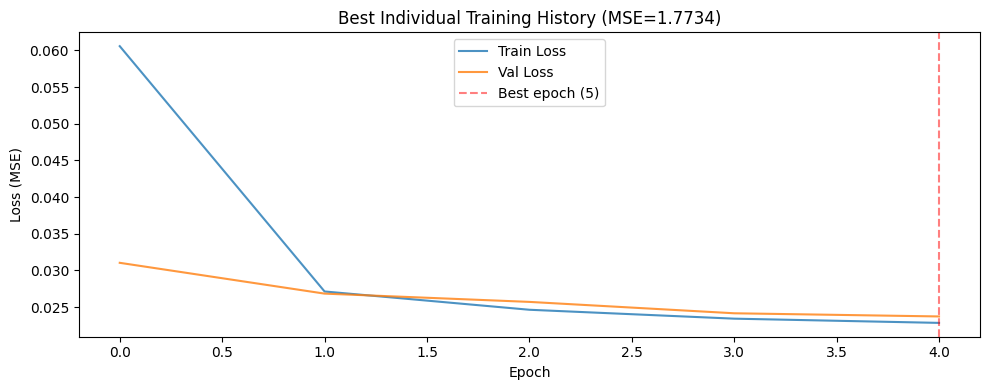

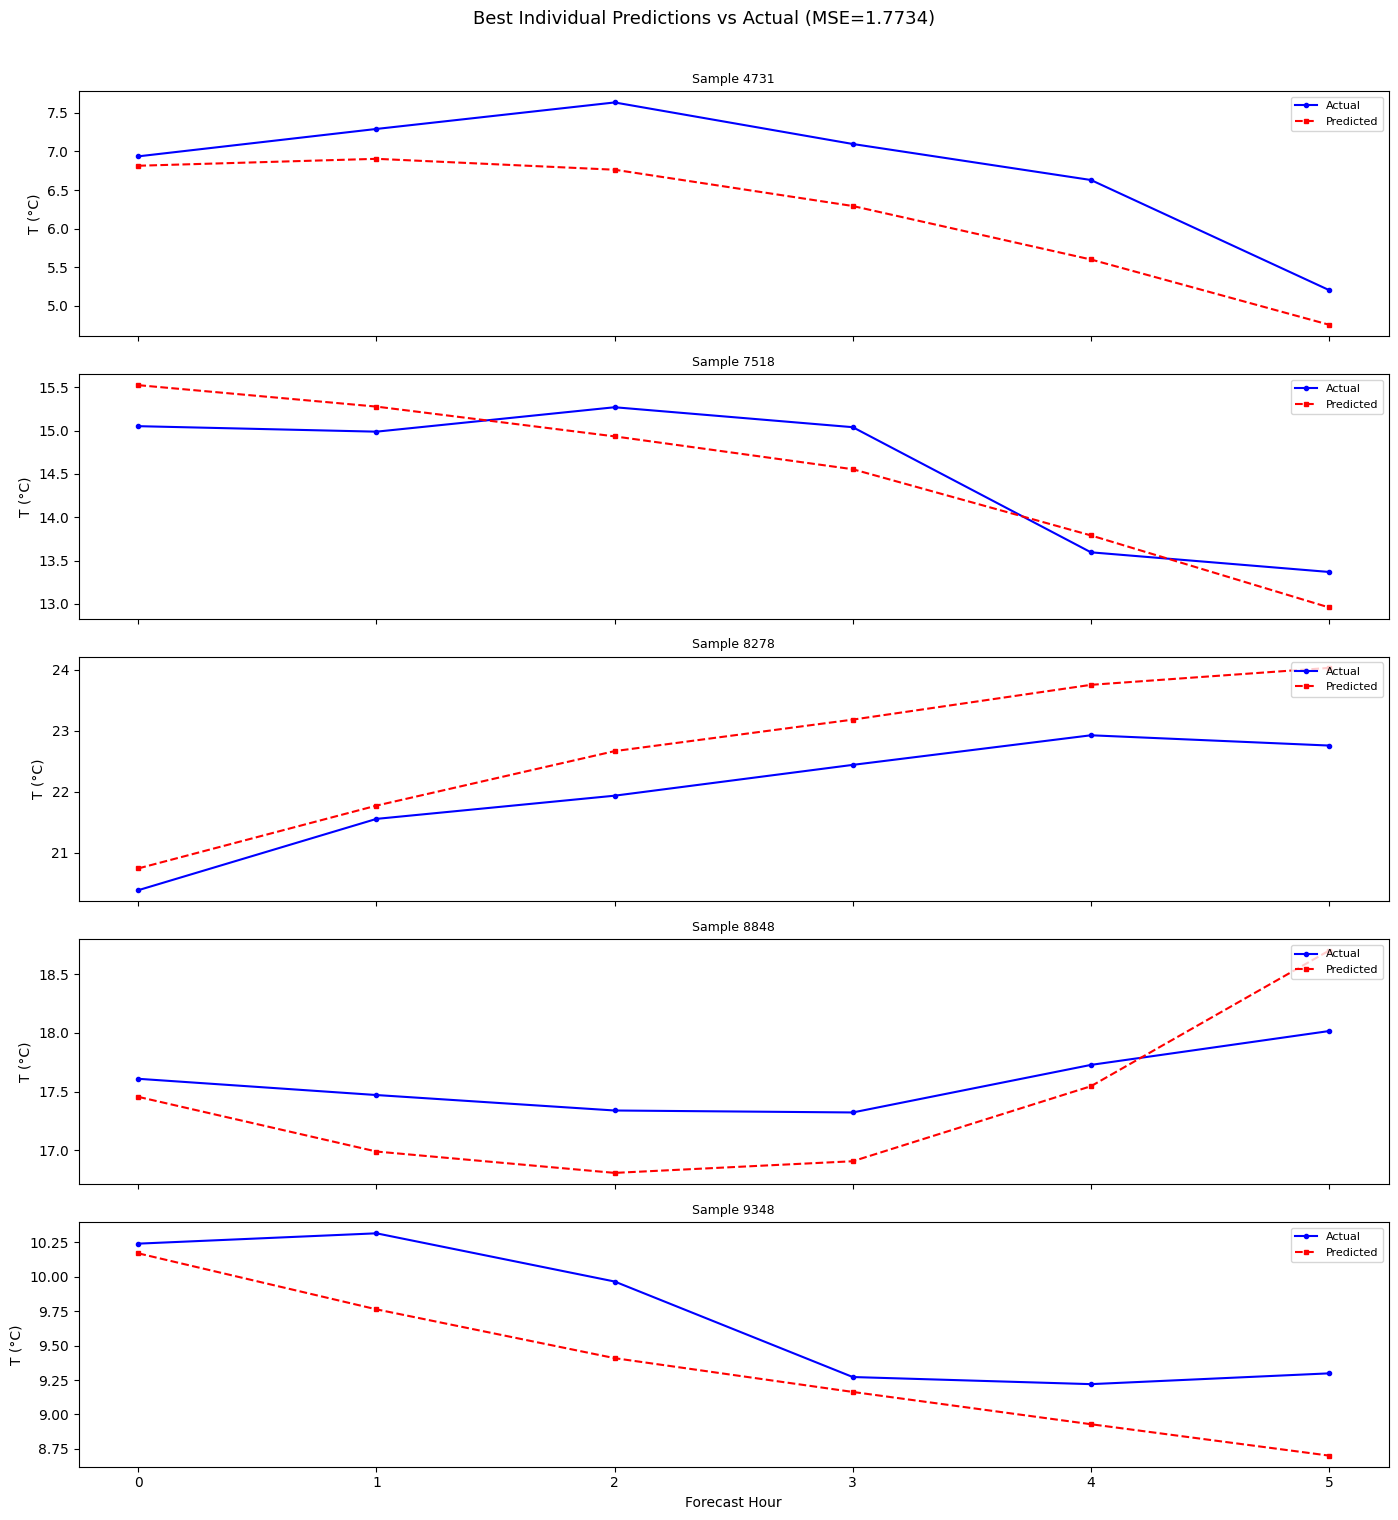

In [41]:
# plots for the best individual
best_fitness = best_overall_tuple[1][0]
best_history = best_overall_tuple[1][3]
best_y_true = best_overall_tuple[1][5]
best_y_pred = best_overall_tuple[1][6]
plot_training_history(best_history, title=f"Best Individual Training History (MSE={best_fitness:.4f})")
plot_predictions(best_y_true, best_y_pred, title=f"Best Individual Predictions vs Actual (MSE={best_fitness:.4f})", n_samples=5)


### 7.3 Evolutionary Strategy & Operators

Define selection, crossover, and mutation operators.

In [ ]:
# TODO: Set up the evolutionary algorithm
# Choose a library/framework: DEAP, Optuna (evolutionary sampler), or custom implementation.
#
# Define:
#   - Population size (e.g. 20-50 individuals)
#   - Number of generations (e.g. 10-30)
#   - Selection strategy (tournament, roulette, NSGA-II for multi-objective)
#   - Crossover operator and probability
#   - Mutation operator and probability
#   - Training budget per individual (reduced epochs to keep search feasible)
#
# POPULATION_SIZE = 20
# NUM_GENERATIONS = 15
# CROSSOVER_PROB  = 0.7
# MUTATION_PROB   = 0.2
# TRAINING_BUDGET = 20  # max epochs per individual during search
#
# TODO: Implement the evolutionary loop
# TODO: Log the best fitness per generation
# TODO: Store the Pareto front if multi-objective

### 7.4 Run Evolutionary Search

In [ ]:
# TODO: Run the evolutionary search
# - This is the main optimization loop
# - Track and display progress (best fitness per generation)
# - Save results for analysis

In [ ]:
# TODO: Visualize evolutionary search results
# - Plot fitness evolution over generations
# - If multi-objective: plot Pareto front
# - Show the best individual's configuration

### 7.5 Overfitting Mitigation & Final Evaluation

**IMPORTANT:** Evolutionary search may overfit to the validation set.

In [ ]:
# TODO: Re-evaluate the best individual(s) with multiple random seeds
# - Train the best configuration with 3-5 different random seeds
# - Report mean and std of validation/test performance
# - This addresses overfitting to a single validation split
#
# TODO: Train the final optimized model with full training budget
# - Use the best configuration from evolutionary search
# - Train with full epochs (not reduced budget)
# - Evaluate on the UNTOUCHED test set
#
# TODO: Compare optimized model vs baseline (quantitatively)

---
## 8. Synthetic Data Generation (Optional/Bonus)

Explore generative approaches (e.g., GAN-based) for data augmentation.

**⚠️ Data Leakage Warning:** Synthetic data must be generated using the **training set only**.

In [ ]:
# TODO (OPTIONAL/BONUS): Implement synthetic data generation
#
# Approaches to consider:
#   - TimeGAN (Generative Adversarial Network for time series)
#   - VAE-based generation
#   - Simple augmentation techniques (jittering, scaling, window warping)
#
# Steps:
#   1. Train a generative model on TRAINING data only
#   2. Generate synthetic time series segments
#   3. Evaluate quality of synthetic data (visual inspection, distribution comparison)
#   4. Augment training set with synthetic data
#   5. Re-train forecasting model with augmented data
#   6. Compare performance WITH vs WITHOUT augmentation
#
# IMPORTANT: No data leakage! Only use training data for generation.

---
## 9. Explainable AI (XAI)

Apply XAI techniques to analyse and interpret the forecasting models.

**Required:**
- At least **one global** explanation method
- At least **one local** explanation method

### 9.1 Global Explainability

Understand the model's overall behaviour and feature importance.

In [ ]:
# TODO: Apply at least ONE global explanation method
#
# Options:
#   - Permutation Feature Importance
#   - SHAP summary plots (global feature importance)
#   - Integrated Gradients (averaged over many samples)
#   - Attention weight analysis (for Transformer models)
#
# Steps:
#   1. Choose and justify the method
#   2. Apply to the trained model
#   3. Visualize results (feature importance bar chart, SHAP beeswarm, etc.)
#   4. Interpret and discuss:
#      - Which features are most important for temperature forecasting?
#      - Does this align with domain knowledge?
#      - How does importance change between baseline and optimized models?

### 9.2 Local Explainability

Explain individual predictions — why did the model predict this specific value?

In [ ]:
# TODO: Apply at least ONE local explanation method
#
# Options:
#   - SHAP values for individual predictions
#   - LIME (Local Interpretable Model-agnostic Explanations)
#   - Integrated Gradients (for specific samples)
#   - Attention visualization (for Transformer — which time steps are attended to)
#   - Saliency maps / gradient-based attribution
#
# Steps:
#   1. Choose and justify the method
#   2. Select interesting sample predictions:
#      - A well-predicted sample
#      - A poorly-predicted sample (high error)
#      - An edge case (e.g., sudden temperature change)
#   3. Visualize explanations for each
#   4. Interpret and discuss:
#      - What drove the prediction for each sample?
#      - Which time steps and features mattered most?
#      - Are error cases explainable?

---
## 10. Efficiency & Resource Analysis

Analyse computational costs and trade-offs between performance and efficiency.

**Required metrics:**
- Training time
- Inference time
- Number of model parameters
- Memory usage (RAM and/or GPU)

In [ ]:
# TODO: Collect efficiency metrics for all models
#
# def count_parameters(model):
#     """Count total number of trainable parameters."""
#     return sum(p.numel() for p in model.parameters() if p.requires_grad)
#
# def measure_inference_time(model, test_loader, device, n_runs=10):
#     """Measure average inference time over multiple runs."""
#     # TODO: Time the full inference pass, average over n_runs
#     pass
#
# def measure_memory_usage(model, sample_input, device):
#     """Measure peak GPU/CPU memory during forward pass."""
#     # TODO: Use torch.cuda.max_memory_allocated() or tracemalloc for CPU
#     pass

In [ ]:
# TODO: Create a comprehensive comparison table
#
# Columns: Model | Params | Train Time | Infer Time | Memory | MSE | MAE | R²
# Rows:    GRU Baseline | Transformer Baseline | EA-Optimized | (Augmented)
#
# efficiency_results = pd.DataFrame({
#     'Model': ['GRU Baseline', 'Transformer Baseline', 'EA-Optimized'],
#     'Parameters': [...],
#     'Training Time (s)': [...],
#     'Inference Time (ms)': [...],
#     'Memory (MB)': [...],
#     'MSE': [...],
#     'MAE': [...],
#     'R²': [...]
# })
# efficiency_results

In [ ]:
# TODO: Visualize trade-offs
# - Plot: Accuracy vs Number of Parameters (scatter plot)
# - Plot: Accuracy vs Training Time
# - Plot: Accuracy vs Inference Time
# - Discuss: Is the additional complexity of the optimized model justified?

---
## 11. Comparative Analysis & Discussion

**This is one of the most important parts of the project.**

Provide a thorough analysis covering all aspects of the work.

### 11.1 Baseline vs Optimized Model Comparison

In [ ]:
# TODO: Compare baseline and optimized models
# - Side-by-side prediction plots
# - Metric comparison table (MSE, RMSE, MAE, MAPE, R²)
# - Statistical significance tests if applicable
# - How much did evolutionary optimization improve performance?

### 11.2 Discussion Points

Address each of these in written analysis (markdown cells):

**TODO: Write detailed discussion covering:**

1. **Impact of Evolutionary Optimization**
   - What improvements did the EA achieve over the baseline?
   - What pipeline components had the largest impact?
   - Did multi-objective optimization reveal interesting trade-offs?

2. **Insights from Explainability (XAI)**
   - What did the global explanations reveal about feature importance?
   - What did local explanations show about individual predictions?
   - Do the explanations align with meteorological domain knowledge?
   - How do explanations differ between baseline and optimized models?

3. **Accuracy vs Complexity vs Efficiency Trade-offs**
   - Is the optimized model significantly better than the baseline?
   - Is the improvement worth the additional complexity?
   - How do training/inference costs scale?

4. **Strengths and Limitations of the Final Solution**
   - What works well?
   - What are the failure modes?
   - What would you do differently with more time/resources?
   - Potential improvements and future work.

---
## 12. Conclusion

**TODO: Write a conclusion summarizing:**

- The problem addressed
- Key findings and results
- The most effective pipeline configuration found
- Main insights from explainability analysis
- Efficiency considerations
- Recommendations for future work